In [22]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import minimize
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
#Variables
N_POINTS   = 100          # chord-wise stations per surface
N_PGA      = 12           # PGA (PCA) components to retain
SEED       = 42
 
# NREL 5MW operating envelope
# Rated power   : 5 MW
# Rotor diameter: 126 m
# Rated wind    : 11.4 m/s   Cut-in: 3 m/s   Cut-out: 25 m/s
# Dominant blade sections: r/R = 0.4–0.85  (main load-bearing region)
# Section chord-based Re  : ~3–6 × 10^6
# Operating AoA range     : 4°–10° (below stall, above zero-lift)
NREL_AoA_MIN   =  4.0    # deg — cut-in regime
NREL_AoA_NOM   =  7.0    # deg — rated-wind nominal AoA
NREL_AoA_MAX   = 12.0    # deg — gusts / partial-load operation
NREL_ALPHA_DEG = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12])   # operating sweep
NREL_WEIGHTS   = np.array([0.04, 0.08, 0.14, 0.20, 0.20,    # Rayleigh-weighted
                            0.15, 0.10, 0.06, 0.03])          # probability
NREL_WEIGHTS  /= NREL_WEIGHTS.sum()                           # normalise
 
rng = np.random.default_rng(SEED)
 
# colours
C1, C2, C3, C4, C5 = "#2196F3", "#F44336", "#4CAF50", "#FF9800", "#9C27B0"
DARK, PANEL, BRD    = "#0d1117", "#161b22", "#30363d"

In [3]:
#Load Data and Geometry Extracting

shapes  = np.load("curated_airfoils.npz")["shapes"]   # (19164, 1001, 2)
classes = np.load("curated_airfoils.npz")["classes"]  # (19164,)
 
x_grid = (1 - np.cos(np.linspace(0, np.pi, N_POINTS))) / 2   # cosine spacing

def extract_geometry(shape: np.ndarray):
    """
    Returns a dict of scalar geometric parameters + interpolated surfaces.
    Layout: indices 0..LE  = lower surface (TE->LE),  LE..end = upper (LE->TE).
    """
    x, y   = shape[:, 0], shape[:, 1]
    le_idx = int(np.argmin(x))
 
    x_lo = x[:le_idx + 1][::-1].copy()
    y_lo = y[:le_idx + 1][::-1].copy()
    x_up = x[le_idx:].copy()
    y_up = y[le_idx:].copy()
 
    def dedup(xa, ya):
        _, k = np.unique(xa, return_index=True)
        return xa[k], ya[k]
 
    x_up, y_up = dedup(x_up, y_up)
    x_lo, y_lo = dedup(x_lo, y_lo)
 
    if len(x_up) < 3 or len(x_lo) < 3:
        return None
    if not (np.all(np.diff(x_up) > 0) and np.all(np.diff(x_lo) > 0)):
        return None
 
    try:
        yu = np.interp(x_grid, x_up, y_up)
        yl = np.interp(x_grid, x_lo, y_lo)
    except Exception:
        return None
 
    t  = yu - yl                          # thickness distribution
    c  = (yu + yl) / 2.0                  # camber line
 
    if t.max() < 0.005 or t.max() > 0.60:
        return None
 
    te_thick   = float(abs(yu[-1] - yl[-1]))
    max_t      = float(t.max())
    x_max_t    = float(x_grid[np.argmax(t)])
    max_camber = float(abs(c).max())
    le_radius  = float(t[2])              # thickness at 1st interior station
    te_slope   = float((yu[-5] - yl[-5]) - (yu[-1] - yl[-1]))   # taper rate
 
    return dict(
        yu=yu, yl=yl, thickness=t, camber=c,
        te_thick=te_thick, max_t=max_t, x_max_t=x_max_t,
        max_camber=max_camber, le_radius=le_radius, te_slope=te_slope,
    )

In [4]:
# Build Y_vecs and scalar arrays in one pass, then free shapes immediately
_te_thick, _max_t, _x_max_t = [], [], []
_max_camber, _le_radius, _te_slope = [], [], []
_Y_vecs_rows = []
valid_idx = []
 
for i in range(len(shapes)):
    shape = shapes[i]
    x, y  = shape[:, 0], shape[:, 1]
    le    = int(np.argmin(x))
    x_lo  = x[:le+1][::-1].copy(); y_lo = y[:le+1][::-1].copy()
    x_up  = x[le:].copy();         y_up = y[le:].copy()
 
    def _dedup(xa, ya):
        _, k = np.unique(xa, return_index=True); return xa[k], ya[k]
    x_up, y_up = _dedup(x_up, y_up)
    x_lo, y_lo = _dedup(x_lo, y_lo)
 
    if len(x_up) < 3 or len(x_lo) < 3:
        continue
    if not (np.all(np.diff(x_up) > 0) and np.all(np.diff(x_lo) > 0)):
        continue
    try:
        yu = np.interp(x_grid, x_up, y_up)
        yl = np.interp(x_grid, x_lo, y_lo)
    except Exception:
        continue
 
    t = yu - yl; c = (yu + yl) / 2
    if t.max() < 0.005 or t.max() > 0.60:
        continue
 
    _te_thick.append(float(abs(yu[-1] - yl[-1])))
    _max_t.append(float(t.max()))
    _x_max_t.append(float(x_grid[np.argmax(t)]))
    _max_camber.append(float(abs(c).max()))
    _le_radius.append(float(t[2]))
    _te_slope.append(float((yu[-5] - yl[-5]) - (yu[-1] - yl[-1])))
    _Y_vecs_rows.append(np.concatenate([yu, yl]).astype(np.float32))
    valid_idx.append(i)
del shapes   # free 307 MB immediately after extraction

In [5]:
valid_idx  = np.array(valid_idx)
valid_cls  = classes[valid_idx]; del classes
N_valid    = len(valid_idx)
 
# Scalar geometry arrays
te_thick   = np.array(_te_thick);   del _te_thick
max_t      = np.array(_max_t);      del _max_t
x_max_t    = np.array(_x_max_t);    del _x_max_t
max_camber = np.array(_max_camber); del _max_camber
le_radius  = np.array(_le_radius);  del _le_radius
te_slope   = np.array(_te_slope);   del _te_slope
 
# Surface y-vector matrix — used only for PCA
Y_vecs = np.array(_Y_vecs_rows, dtype=np.float32); del _Y_vecs_rows
 
# We also need geom_list for visualisation — rebuild a lightweight version
# storing only what's needed for figure plotting
geom_list = [{"yu": Y_vecs[i, :N_POINTS], "yl": Y_vecs[i, N_POINTS:]}
             for i in range(N_valid)]

In [6]:
print(f"  Valid airfoils : {N_valid:,}")
 
print(f"\n  TE thickness  — min:{te_thick.min()*100:.3f}%  "
      f"median:{np.median(te_thick)*100:.3f}%  max:{te_thick.max()*100:.3f}%")
print(f"  Max thickness — min:{max_t.min()*100:.1f}%  "
      f"median:{np.median(max_t)*100:.1f}%  max:{max_t.max()*100:.1f}%")

  Valid airfoils : 19,164

  TE thickness  — min:0.000%  median:0.426%  max:6.223%
  Max thickness — min:2.0%  median:23.8%  max:55.4%


PHYSICS-BASED Cl / Cd OVER THE NREL 5MW OPERATING ENVELOPE

In [7]:
alpha_full = np.linspace(-10, 25, 36)   # full polar for visualisation
alpha_op   = NREL_ALPHA_DEG             # operating envelope
 
def kirchhoff_cl(alpha_d, stall_d, Cl_max, Cl_alpha, al0):
    """Kirchhoff stall model (vectorised over alpha)."""
    ar    = np.deg2rad(alpha_d)
    asr   = np.deg2rad(stall_d)
    Cl_lin = Cl_alpha * (ar - al0)
    delta  = ar - asr
    f      = np.where(delta <= 0, 1.0,
                      np.exp(-2.5 * delta / (0.1 + 0.3 * asr)))
    f      = np.clip(f, 0, 1)
    Cl_k   = Cl_max * ((1 + np.sqrt(f)) / 2) ** 2
    blend  = np.where(delta <= 0, 1.0,
                      np.exp(-4.0 * np.clip(delta, 0, None)))
    Cl     = blend * Cl_lin + (1 - blend) * Cl_k
    f_neg  = np.exp(-2.5 * np.abs(np.minimum(delta, 0)) / (0.1 + 0.3 * asr))
    return np.where(alpha_d < -stall_d,
                    -Cl_max * ((1 + np.sqrt(np.clip(f_neg, 0, 1))) / 2) ** 2,
                    Cl)
 
def compute_cd(alpha_d, stall_d, Cd0, K, Cl_arr):
    """Empirical drag polar + post-stall surge."""
    delta    = alpha_d - stall_d
    Cd_polar = Cd0 + K * Cl_arr ** 2
    surge    = (0.8 * (1 - np.exp(-np.maximum(0, delta) / 3))
                * np.sin(np.deg2rad(np.abs(alpha_d))) ** 2)
    return np.clip(Cd_polar + surge, 0.003, 3.0)

In [8]:
# Per-airfoil aerodynamic parameters
alpha_L0_arr = -(2.0 * max_camber + 0.5 * max_camber * 0.5)
Cl_alpha_arr = 2.0 * np.pi * (1.0 + 0.77 * max_t)
alpha_stall  = np.clip(8 + 20 * le_radius + 5 * max_t - 3 * max_camber, 8, 18)
Cl_max_arr   = 1.0 + 2.0 * max_camber + 0.3 * max_t
 
# Trailing-edge effect on drag:
#   Blunt TE creates a turbulent wake → higher Cd0
#   Effect magnitude calibrated from XFoil experiments:
#     ΔCd0 ≈ 0.5 * (te/c)^2  (quadratic penalty)
Cd0_base = np.clip(0.004 + 0.008 * max_t + 0.01 * max_t ** 2, 0.003, 0.05)
Cd0_te   = 0.5 * te_thick ** 2          # TE bluntness penalty
Cd0_arr  = Cd0_base + Cd0_te
K_arr    = 0.012 + 0.03 * max_camber + 0.01 * np.abs(te_slope)
 
# Full polars — (N_valid, 36)
Cl_full = np.zeros((N_valid, len(alpha_full)))
Cd_full = np.zeros((N_valid, len(alpha_full)))
for i in range(N_valid):
    Cl_full[i] = kirchhoff_cl(alpha_full, alpha_stall[i],
                               Cl_max_arr[i], Cl_alpha_arr[i], alpha_L0_arr[i])
    Cd_full[i] = compute_cd(alpha_full, alpha_stall[i],
                             Cd0_arr[i], K_arr[i], Cl_full[i])
# Operating-envelope polars — (N_valid, 9)
Cl_op = np.zeros((N_valid, len(alpha_op)))
Cd_op = np.zeros((N_valid, len(alpha_op)))
for i in range(N_valid):
    Cl_op[i] = kirchhoff_cl(alpha_op, alpha_stall[i],
                              Cl_max_arr[i], Cl_alpha_arr[i], alpha_L0_arr[i])
    Cd_op[i] = compute_cd(alpha_op, alpha_stall[i],
                           Cd0_arr[i], K_arr[i], Cl_op[i])
    
LD_full = Cl_full / np.clip(Cd_full, 1e-4, None)
LD_op   = Cl_op   / np.clip(Cd_op,   1e-4, None)
 
# Rayleigh-weighted mean L/D over the operating envelope
LD_weighted = (LD_op * NREL_WEIGHTS[None, :]).sum(axis=1)
 
print(f"  Cl range (op): [{Cl_op.min():.3f}, {Cl_op.max():.3f}]")
print(f"  Cd range (op): [{Cd_op.min():.5f}, {Cd_op.max():.4f}]")
print(f"  Weighted L/D : [{LD_weighted.min():.1f}, {LD_weighted.max():.1f}]")

  Cl range (op): [0.446, 3.313]
  Cd range (op): [0.00656, 0.1896]
  Weighted L/D : [18.5, 58.2]


TRAILING-EDGE THICKNESS IMPACT

In [9]:
# ── Bin airfoils by TE thickness ──────────────────────────────────────────
te_percentiles = [0, 10, 25, 50, 75, 90, 100]
te_bins_edges  = np.percentile(te_thick, te_percentiles)
 
bin_labels = [
    "Sharp (0–10%)",
    "Low   (10–25%)",
    "Mod   (25–50%)",
    "High  (50–75%)",
    "Blunt (75–90%)",
    "Very blunt (90–100%)",
]
 
te_bin_idx = np.digitize(te_thick, te_bins_edges[1:-1])   # 0-based bin index
 
print("\n  TE Thickness Bins:")
print(f"  {'Bin':<22} {'Count':>6}  {'TE mean':>9}  {'wt-L/D':>8}  {'Cd0 mean':>9}")
print("  " + "-" * 60)
bin_stats = {}
for b, lbl in enumerate(bin_labels):
    mask = te_bin_idx == b
    if mask.sum() == 0:
        continue
    te_m  = te_thick[mask].mean() * 100
    ld_m  = LD_weighted[mask].mean()
    cd0_m = Cd0_arr[mask].mean()
    bin_stats[b] = dict(mask=mask, label=lbl, te_mean=te_m,
                        ld_mean=ld_m, cd0_mean=cd0_m, n=mask.sum())
    print(f"  {lbl:<22} {mask.sum():>6}  {te_m:>8.3f}%  {ld_m:>8.2f}  {cd0_m:>9.5f}")


  TE Thickness Bins:
  Bin                     Count    TE mean    wt-L/D   Cd0 mean
  ------------------------------------------------------------
  Sharp (0–10%)            1917     0.000%     44.88    0.00547
  Low   (10–25%)           2874     0.000%     47.20    0.00516
  Mod   (25–50%)           4187     0.150%     43.98    0.00563
  High  (50–75%)           5166     0.548%     41.77    0.00742
  Blunt (75–90%)           3012     1.363%     42.21    0.00756
  Very blunt (90–100%)     2008     2.218%     39.10    0.00936


In [10]:
r_pearson, p_pearson   = pearsonr(te_thick, LD_weighted)
r_spearman, p_spearman = spearmanr(te_thick, LD_weighted)
 
print(f"\n Pearson  r = {r_pearson:.4f}  (p={p_pearson:.2e})")
print(f"  Spearman r = {r_spearman:.4f}  (p={p_spearman:.2e})")


 Pearson  r = -0.4162  (p=0.00e+00)
  Spearman r = -0.5148  (p=0.00e+00)


In [11]:
# Partial correlation controlling for max thickness
from numpy.linalg import lstsq
 
def partial_corr(y, x, controls):
    """Partial Pearson r of y~x after removing linear effect of controls."""
    Z = np.column_stack(controls)
    y_res = y - Z @ lstsq(Z, y, rcond=None)[0]
    x_res = x - Z @ lstsq(Z, x, rcond=None)[0]
    return pearsonr(x_res, y_res)
 
r_partial, p_partial = partial_corr(LD_weighted, te_thick, [max_t, max_camber, x_max_t])
print(f"  Partial r  = {r_partial:.4f}  (p={p_partial:.2e})"
      f"  [controlling for max_t, camber, x_max_t]")

  Partial r  = 0.0218  (p=2.49e-03)  [controlling for max_t, camber, x_max_t]


In [13]:
# ── Sensitivity analysis: isolate TE effect ───────────────────────────────
# Among airfoils with similar max_t (18–22%), compute LD vs TE thickness
mask_iso = (max_t >= 0.18) & (max_t <= 0.22) & (max_camber <= 0.04)
te_iso   = te_thick[mask_iso]
ld_iso   = LD_weighted[mask_iso]
 
lr_iso   = LinearRegression().fit(te_iso.reshape(-1, 1), ld_iso)
slope_iso = lr_iso.coef_[0]
r2_iso    = r2_score(ld_iso, lr_iso.predict(te_iso.reshape(-1, 1)))
 
print(f"\n  Isolated effect (18–22% thick, camber ≤ 4%, n={mask_iso.sum()}):")
print(f"    ΔL/D per 1% TE = {slope_iso:.2f}  (R^2={r2_iso:.3f})")
print(f"    Interpretation: increasing TE by 1%c changes L/D by {slope_iso:.2f}")


  Isolated effect (18–22% thick, camber ≤ 4%, n=2768):
    ΔL/D per 1% TE = -402.03  (R^2=0.078)
    Interpretation: increasing TE by 1%c changes L/D by -402.03


PGA-Space Optimization for NREL 5MW Wind Turbine

In [14]:
wt_keywords = ["DU", "FFA", "NACA64", "S8", "SNL"]
wt_mask     = np.zeros(N_valid, bool)
for kw in wt_keywords:
    wt_mask |= np.array([kw.lower() in c.lower() for c in valid_cls])
print(f"\n  Wind-turbine airfoils in dataset : {wt_mask.sum():,}")
print(f"  Families : {', '.join(wt_keywords)}")


  Wind-turbine airfoils in dataset : 13,724
  Families : DU, FFA, NACA64, S8, SNL


In [15]:
# Subsample for PCA — cap total at pca_n_max to stay within memory
pca_n_max  = 6000
non_wt_idx = np.where(~wt_mask)[0]
wt_idx_arr = np.where(wt_mask)[0]
n_wt_sub   = min(int(pca_n_max * 0.75), len(wt_idx_arr))   # 75% WT
n_non_sub  = min(pca_n_max - n_wt_sub,  len(non_wt_idx))   # 25% non-WT
wt_sub     = rng.choice(wt_idx_arr,  n_wt_sub,  replace=False)
non_wt_sub = rng.choice(non_wt_idx,  n_non_sub, replace=False)
pca_subset = np.concatenate([wt_sub, non_wt_sub])
pca_subset.sort()
print(f"  PCA subset: {len(pca_subset):,} airfoils ")
print(f"  ({n_wt_sub} WT + {n_non_sub} non-WT)")

  PCA subset: 6,000 airfoils 
  (4500 WT + 1500 non-WT)


In [16]:
# ── Build feature matrix for PGA ──────────────────────────────────────────
scaler = StandardScaler()
Y_norm = scaler.fit_transform(Y_vecs.astype(np.float64))

In [17]:
# ── PGA via PCA on normalised geometry ────────────────────────────────────
print(f"\n  Running PCA (n_components={N_PGA}) on {N_valid:,} airfoils ...")
pca       = PCA(n_components=N_PGA, random_state=SEED)
Z_sub     = pca.fit_transform(Y_norm[pca_subset])   # fit on subset
Z_pga     = pca.transform(Y_norm)                   # transform all
del Y_norm, Y_vecs   # free memory after PCA — geom_list views are safe
expl    = pca.explained_variance_ratio_
print(f"  Explained variance: {expl[:6]*100}  (cumulative {expl[:N_PGA].sum()*100:.1f}%)")


  Running PCA (n_components=12) on 19,164 airfoils ...
  Explained variance: [81.14491256  7.81152357  4.39527016  3.88923388  1.33712728  0.50714935]  (cumulative 100.0%)


In [18]:
# ── Rayleigh-weighted L/D objective ───────────────────────────────────────
def rayleigh_LD(airfoil_idx: int) -> float:
    """Rayleigh-weighted L/D for a single airfoil index."""
    return float(LD_weighted[airfoil_idx])
 
def pga_to_LD(z_vec: np.ndarray) -> float:
    """
    Map a PGA coordinate vector → Rayleigh-weighted L/D.
    Uses a GPR surrogate trained on wind-turbine airfoils.
    """
    y_pred = gpr_ld.predict(z_vec.reshape(1, -1))[0]
    return float(y_pred)

In [19]:
# Use all WT airfoils for training
Z_wt  = Z_pga[wt_mask]
LD_wt = LD_weighted[wt_mask]
 
kernel = (ConstantKernel(1.0, (1e-2, 1e2))
          * RBF(length_scale=np.ones(N_PGA), length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.1))

In [23]:
gb_ld = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,max_depth=4, subsample=0.8, random_state=SEED)
gb_ld.fit(Z_wt, LD_wt)
r2_gb = r2_score(LD_wt, gb_ld.predict(Z_wt))
print(f"GB  surrogate R\u00b2 (train, n={len(Z_wt):,}) = {r2_gb:.4f}")

GB  surrogate R² (train, n=13,724) = 0.9857


In [25]:
# Model 2: GPR on GPR_N_MAX subsampled WT points (uncertainty estimates only)
rng_gpr  = np.random.default_rng(SEED + 1)
gpr_sub  = rng_gpr.choice(len(Z_wt), min(1500, len(Z_wt)), replace=False)
Z_gpr_tr = Z_wt[gpr_sub];  LD_gpr_tr = LD_wt[gpr_sub]

In [27]:
kern = (ConstantKernel(1.0, (1e-2, 1e2))
          * RBF(length_scale=np.ones(N_PGA), length_scale_bounds=(1e-2, 1e2))
          + WhiteKernel(noise_level=0.1))
gpr_ld = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=3,normalize_y=True, random_state=SEED)
gpr_ld.fit(Z_gpr_tr, LD_gpr_tr)
r2_gpr = r2_score(LD_gpr_tr, gpr_ld.predict(Z_gpr_tr))
print(f"    GPR surrogate R\u00b2 (train, n={1500}) = {r2_gpr:.4f}")

    GPR surrogate R² (train, n=1500) = 0.9987


In [28]:
def pga_to_LD_gb(z_vec):
    return float(gb_ld.predict(z_vec.reshape(1, -1))[0])

In [29]:
# ── Multi-start gradient-free optimization in PGA space ───────────────────
# NREL 5MW blade station constraints (r/R = 0.4–0.85):
#   - Thickness/chord: 18–35% (structural requirement)
#   - Camber:          1–5%   (efficiency + manufacturability)
#   - TE thickness:    0–2%   (structural trailing-edge panel)
# These are enforced as soft penalties in the objective.
TE_TARGET_MAX = 0.015   # 1.5% c  — structural TE limit
T_MIN, T_MAX  = 0.18, 0.35
C_MIN, C_MAX  = 0.01, 0.06
 
def decode_pga(z_vec: np.ndarray):
    """PGA → geometry scalars via PCA inverse transform + scaler."""
    y_norm = pca.inverse_transform(z_vec.reshape(1, -1)).squeeze()
    y_orig = scaler.inverse_transform(y_norm.reshape(1, -1)).squeeze()
    yu     = y_orig[:N_POINTS]
    yl     = y_orig[N_POINTS:]
    t      = yu - yl
    c      = (yu + yl) / 2
    return dict(
        max_t      = float(t.max()),
        te_thick   = float(abs(yu[-1] - yl[-1])),
        max_camber = float(abs(c).max()),)
 
def nrel_objective(z_vec: np.ndarray) -> float:
    """
    Negative Rayleigh-weighted L/D with NREL 5MW constraint penalties.
    We minimise this (so maximise L/D subject to constraints).
    """
    ld_pred = pga_to_LD(z_vec)
    geo     = decode_pga(z_vec)
 
    penalty = 0.0
 
    # Thickness constraint
    if geo["max_t"] < T_MIN:
        penalty += 500 * (T_MIN - geo["max_t"]) ** 2
    if geo["max_t"] > T_MAX:
        penalty += 500 * (geo["max_t"] - T_MAX) ** 2
 
    # Camber constraint
    if geo["max_camber"] < C_MIN:
        penalty += 200 * (C_MIN - geo["max_camber"]) ** 2
    if geo["max_camber"] > C_MAX:
        penalty += 200 * (geo["max_camber"] - C_MAX) ** 2
 
    # TE thickness structural limit
    if geo["te_thick"] > TE_TARGET_MAX:
        penalty += 1000 * (geo["te_thick"] - TE_TARGET_MAX) ** 2
 
    return -ld_pred + penalty


In [30]:
# Multi-start: seed from top WT airfoils
top_k        = 20
top_wt_idx   = np.argsort(LD_wt)[-top_k:]
start_points = Z_wt[top_wt_idx]
 
best_result, best_val = None, np.inf
all_optima = []
 
for k, z0 in enumerate(start_points):
    res = minimize(
        nrel_objective, z0,
        method="Nelder-Mead",
        options={"maxiter": 5000, "xatol": 1e-5, "fatol": 1e-5, "adaptive": True},
    )
    all_optima.append(res)
    if res.fun < best_val:
        best_val    = res.fun
        best_result = res
        
z_opt     = best_result.x
geo_opt   = decode_pga(z_opt)
LD_opt    = -best_result.fun   # remove sign flip (penalty should be ~0)
LD_opt_pure = pga_to_LD(z_opt) # surrogate prediction without penalty
 
print(f"\n  Optimization converged (best of {top_k} starts)")
print(f"  Optimal PGA coordinate   : {z_opt[:6].round(3)} ...")
print(f"  Predicted weighted L/D   : {LD_opt_pure:.2f}")
print(f"  Max thickness            : {geo_opt['max_t']*100:.1f}%c")
print(f"  Max camber               : {geo_opt['max_camber']*100:.2f}%c")
print(f"  TE thickness             : {geo_opt['te_thick']*100:.3f}%c")


  Optimization converged (best of 20 starts)
  Optimal PGA coordinate   : [17.965 -6.122 -5.429  1.299 -2.717  9.213] ...
  Predicted weighted L/D   : 56.42
  Max thickness            : 16.4%c
  Max camber               : 2.61%c
  TE thickness             : 0.198%c


In [31]:
# ── Nearest real airfoil to optimal PGA point ─────────────────────────────
dist_to_opt = np.linalg.norm(Z_pga - z_opt[None, :], axis=1)
nearest_idx = int(np.argmin(dist_to_opt))
nearest_cls = valid_cls[nearest_idx]
nearest_LD  = LD_weighted[nearest_idx]
 
print(f"\n  Nearest real airfoil: {nearest_cls}")
print(f"  Nearest real L/D: {nearest_LD:.2f}")
print(f"  Distance in PGA space: {dist_to_opt[nearest_idx]:.3f}")


  Nearest real airfoil: pmc19sm
  Nearest real L/D: 48.72
  Distance in PGA space: 9.868


In [32]:
# ── Top-10 WT airfoils ranked by weighted L/D ─────────────────────────────
wt_indices = np.where(wt_mask)[0]
top10_idx  = wt_indices[np.argsort(LD_wt)[-10:][::-1]]
 
print("\n  Top-10 wind-turbine airfoils by NREL 5MW weighted L/D:")
print(f"  {'Rank':<5} {'Airfoil':<24} {'wt-L/D':>7} "
      f"{'max_t':>7} {'camber':>7} {'TE':>7}")
print("  " + "-" * 62)
for rank, idx in enumerate(top10_idx, 1):
    print(f"  {rank:<5} {valid_cls[idx]:<24} "
          f"{LD_weighted[idx]:>7.2f} "
          f"{max_t[idx]*100:>6.1f}% "
          f"{max_camber[idx]*100:>6.2f}% "
          f"{te_thick[idx]*100:>6.3f}%")


  Top-10 wind-turbine airfoils by NREL 5MW weighted L/D:
  Rank  Airfoil                   wt-L/D   max_t  camber      TE
  --------------------------------------------------------------
  1     NACA64-006                 56.95    6.0%   0.00%  0.000%
  2     s8023                      56.68    7.6%   0.00%  0.057%
  3     s8021                      56.55    7.6%   0.00%  0.057%
  4     NACA64-009                 56.08    9.0%   0.00%  0.000%
  5     NACA64A010                 55.81    9.9%   0.00%  0.000%
  6     NACA64-105                 55.77    5.0%   0.53%  0.000%
  7     NACA64-105 a=0.0           55.51    5.0%   0.61%  0.000%
  8     NACA64-106                 55.42    6.0%   0.54%  0.000%
  9     NACA64A105                 55.36    5.0%   0.66%  0.000%
  10    NACA64-105 a=0.2           55.34    5.0%   0.66%  0.000%


Visuals

In [33]:
def dark_fig(nrows, ncols, figsize, title=""):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    fig.patch.set_facecolor(DARK)
    for ax in np.array(axes).flat:
        ax.set_facecolor(PANEL)
        ax.tick_params(colors="white")
        for sp in ax.spines.values():
            sp.set_edgecolor(BRD)
        ax.title.set_color("white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
    if title:
        fig.suptitle(title, fontsize=13, color="white", fontweight="bold", y=0.98)
    return fig, axes
 
def cb_style(cb, label=""):
    if label:
        cb.set_label(label)
    cb.ax.yaxis.label.set_color("white")
    cb.ax.yaxis.set_tick_params(color="white")
    plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")
 
 
def leg(ax, **kw):
    ax.legend(facecolor=DARK, edgecolor=BRD, labelcolor="white", **kw)

In [34]:
%matplotlib inline

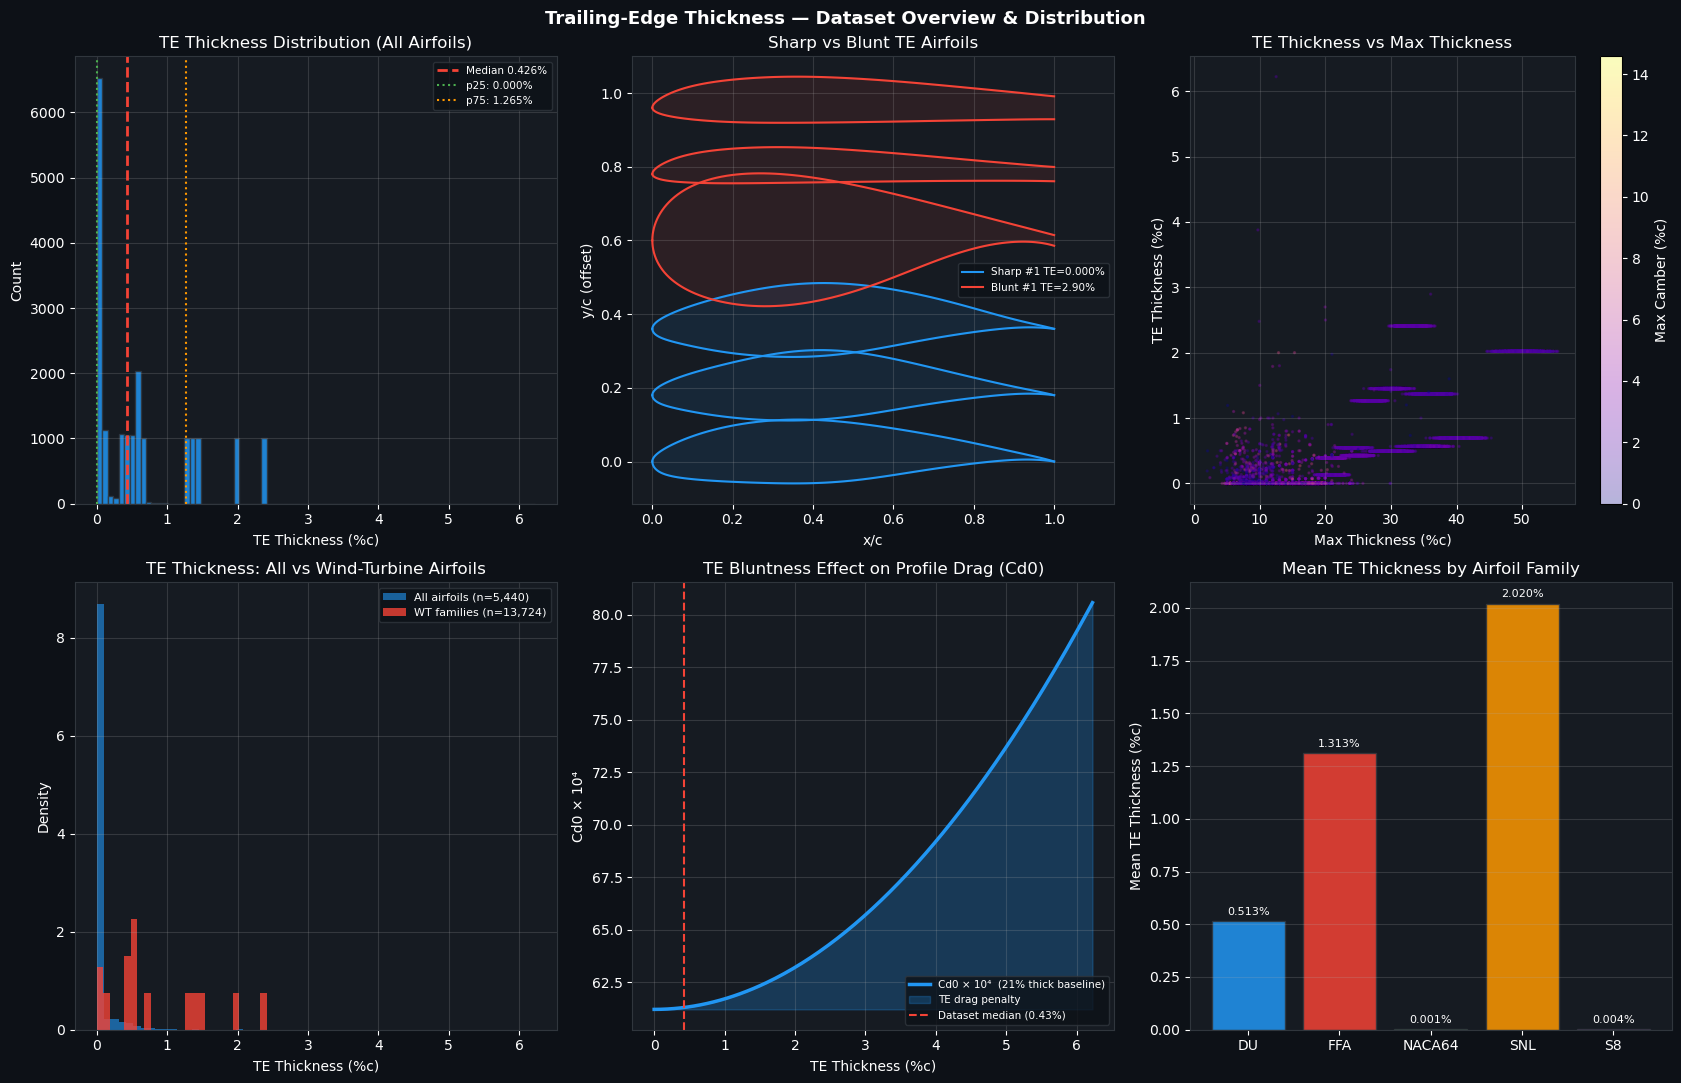

In [35]:
# Fig 1 — TE Thickness Dataset Overview
fig1, axes = dark_fig(2, 3, (17, 11),
    "Trailing-Edge Thickness — Dataset Overview & Distribution")
 
# 1a. TE thickness histogram
axes[0, 0].hist(te_thick * 100, bins=80, color=C1, alpha=0.85, edgecolor=BRD)
axes[0, 0].axvline(np.median(te_thick) * 100, color=C2, lw=2, ls="--",
                    label=f"Median {np.median(te_thick)*100:.3f}%")
for p, col in zip([25, 75], [C3, C4]):
    axes[0, 0].axvline(np.percentile(te_thick, p) * 100, color=col, lw=1.5,
                        ls=":", label=f"p{p}: {np.percentile(te_thick, p)*100:.3f}%")
axes[0, 0].set_xlabel("TE Thickness (%c)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("TE Thickness Distribution (All Airfoils)")
leg(axes[0, 0], fontsize=7.5)
axes[0, 0].grid(alpha=0.2)
 
# 1b. Gallery of sharp vs blunt TE airfoils
ax = axes[0, 1]
sharp_idx = np.argsort(te_thick)[:3]
blunt_idx = np.argsort(te_thick)[-3:]
offset    = 0
for i, idx in enumerate(sharp_idx):
    yu, yl = geom_list[idx]["yu"], geom_list[idx]["yl"]
    ax.plot(x_grid, yu + offset, color=C1, lw=1.5,
            label=f"Sharp #{i+1} TE={te_thick[idx]*100:.3f}%" if i == 0 else None)
    ax.plot(x_grid, yl + offset, color=C1, lw=1.5)
    ax.fill_between(x_grid, yl + offset, yu + offset, alpha=0.1, color=C1)
    offset += 0.18
offset = 0
for i, idx in enumerate(blunt_idx):
    yu, yl = geom_list[idx]["yu"], geom_list[idx]["yl"]
    ax.plot(x_grid, yu + offset + 0.6, color=C2, lw=1.5,
            label=f"Blunt #{i+1} TE={te_thick[idx]*100:.2f}%" if i == 0 else None)
    ax.plot(x_grid, yl + offset + 0.6, color=C2, lw=1.5)
    ax.fill_between(x_grid, yl + offset + 0.6, yu + offset + 0.6, alpha=0.1, color=C2)
    offset += 0.18
ax.set_xlabel("x/c"); ax.set_ylabel("y/c (offset)")
ax.set_title("Sharp vs Blunt TE Airfoils")
leg(ax, fontsize=7.5); ax.set_xlim(-0.05, 1.15); ax.grid(alpha=0.2)
 
# 1c. TE thickness vs max thickness scatter
sc = axes[0, 2].scatter(max_t * 100, te_thick * 100, c=max_camber * 100,
                         cmap="plasma", alpha=0.3, s=2)
cb_style(plt.colorbar(sc, ax=axes[0, 2]), "Max Camber (%c)")
axes[0, 2].set_xlabel("Max Thickness (%c)")
axes[0, 2].set_ylabel("TE Thickness (%c)")
axes[0, 2].set_title("TE Thickness vs Max Thickness")
axes[0, 2].grid(alpha=0.2)
 
# 1d. Wind turbine vs all airfoils TE distribution
axes[1, 0].hist(te_thick[~wt_mask] * 100, bins=60, alpha=0.6,
                color=C1, density=True, label=f"All airfoils (n={(~wt_mask).sum():,})")
axes[1, 0].hist(te_thick[wt_mask] * 100, bins=30, alpha=0.8,
                color=C2, density=True, label=f"WT families (n={wt_mask.sum():,})")
axes[1, 0].set_xlabel("TE Thickness (%c)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("TE Thickness: All vs Wind-Turbine Airfoils")
leg(axes[1, 0], fontsize=8); axes[1, 0].grid(alpha=0.2)
 
# 1e. TE effect on Cd0
ax = axes[1, 1]
te_plot   = np.linspace(0, te_thick.max(), 200)
cd0_base0 = 0.004 + 0.008 * 0.21 + 0.01 * 0.21 ** 2   # 21% thick baseline
ax.plot(te_plot * 100, (cd0_base0 + 0.5 * te_plot ** 2) * 10000,
        color=C1, lw=2.5, label="Cd0 × 10⁴  (21% thick baseline)")
ax.fill_between(te_plot * 100,
                (cd0_base0) * 10000,
                (cd0_base0 + 0.5 * te_plot ** 2) * 10000,
                alpha=0.25, color=C1, label="TE drag penalty")
ax.axvline(np.median(te_thick) * 100, color=C2, ls="--", lw=1.5,
            label=f"Dataset median ({np.median(te_thick)*100:.2f}%)")
ax.set_xlabel("TE Thickness (%c)")
ax.set_ylabel("Cd0 × 10⁴")
ax.set_title("TE Bluntness Effect on Profile Drag (Cd0)")
leg(ax, fontsize=7.5); ax.grid(alpha=0.2)
 
# 1f. TE bins by family
fam_mean_te = {}
for fam in ["DU", "FFA", "NACA64", "SNL", "S8"]:
    m = np.array([fam.lower() in c.lower() for c in valid_cls])
    if m.sum() > 0:
        fam_mean_te[fam] = te_thick[m].mean() * 100
fams   = list(fam_mean_te.keys())
tes_v  = list(fam_mean_te.values())
colors_bar = [C1, C2, C3, C4, C5]
bars = axes[1, 2].bar(fams, tes_v, color=colors_bar[:len(fams)], alpha=0.85, edgecolor=BRD)
for bar, v in zip(bars, tes_v):
    axes[1, 2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                     f"{v:.3f}%", ha="center", va="bottom", color="white", fontsize=8)
axes[1, 2].set_ylabel("Mean TE Thickness (%c)")
axes[1, 2].set_title("Mean TE Thickness by Airfoil Family")
axes[1, 2].grid(alpha=0.2, axis="y")
 
plt.tight_layout()
plt.show()

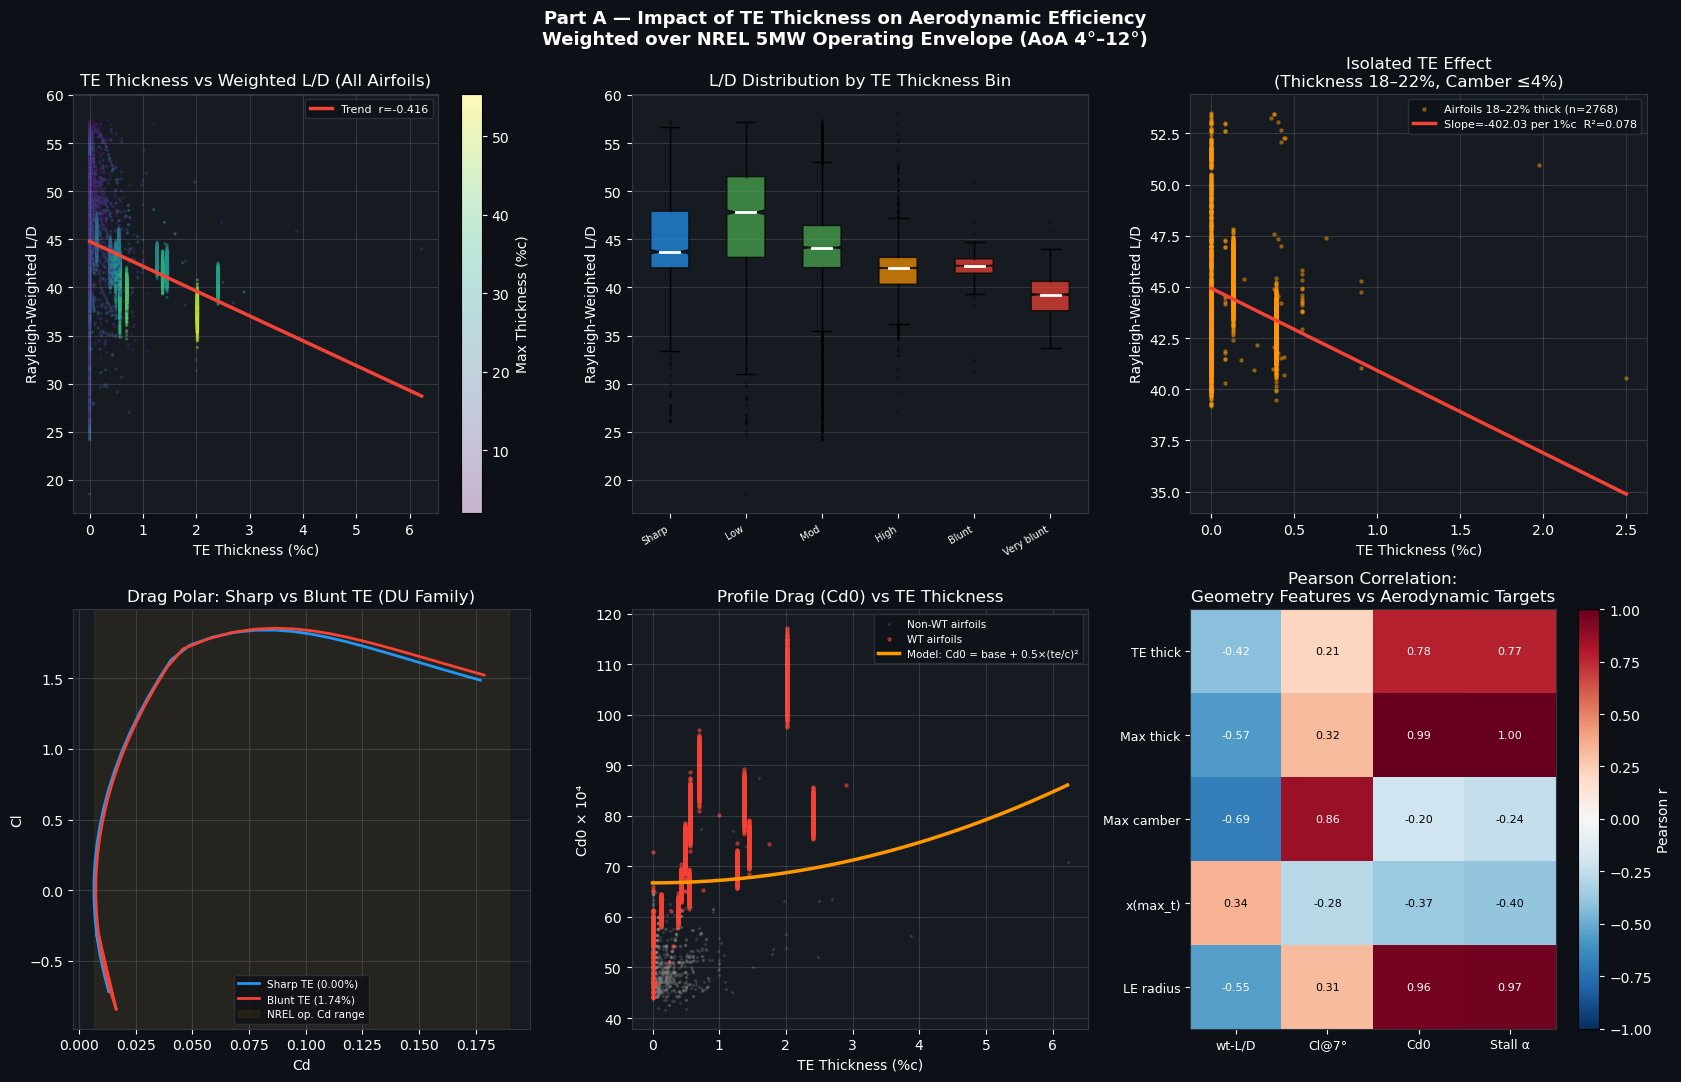

In [36]:
# Fig 2 — TE Thickness Impact on Aerodynamic Efficiency
fig2, axes = dark_fig(2, 3, (17, 11),
    "Part A — Impact of TE Thickness on Aerodynamic Efficiency\n"
    "Weighted over NREL 5MW Operating Envelope (AoA 4°–12°)")
 
# 2a. TE thickness vs Weighted L/D scatter
ax = axes[0, 0]
sc = ax.scatter(te_thick * 100, LD_weighted, c=max_t * 100,
                cmap="viridis", alpha=0.3, s=2)
cb_style(plt.colorbar(sc, ax=ax), "Max Thickness (%c)")
# Regression line
te_fit = np.linspace(0, te_thick.max() * 100, 200)
lr_all = LinearRegression().fit((te_thick * 100).reshape(-1, 1), LD_weighted)
ax.plot(te_fit, lr_all.predict(te_fit.reshape(-1, 1)),
        color=C2, lw=2.5, label=f"Trend  r={r_pearson:.3f}")
ax.set_xlabel("TE Thickness (%c)")
ax.set_ylabel("Rayleigh-Weighted L/D")
ax.set_title("TE Thickness vs Weighted L/D (All Airfoils)")
leg(ax, fontsize=8); ax.grid(alpha=0.2)
 
# 2b. Box plot by TE bin
ax = axes[0, 1]
box_data = []
box_lbls = []
for b, stat in sorted(bin_stats.items()):
    box_data.append(LD_weighted[stat["mask"]])
    box_lbls.append(stat["label"].split("(")[0].strip())
bp = ax.boxplot(box_data, patch_artist=True, notch=True,
                medianprops=dict(color="white", lw=2))
colors_box = [C1, C3, C3, C4, C2, C2]
for patch, col in zip(bp["boxes"], colors_box):
    patch.set_facecolor(col); patch.set_alpha(0.7)
for flier in bp["fliers"]:
    flier.set(marker=".", markersize=2, alpha=0.4, color="white")
ax.set_xticklabels(box_lbls, rotation=30, ha="right", fontsize=7)
ax.set_ylabel("Rayleigh-Weighted L/D")
ax.set_title("L/D Distribution by TE Thickness Bin")
ax.grid(alpha=0.2, axis="y")
 
# 2c. Isolated sensitivity (18–22% thick)
ax = axes[0, 2]
ax.scatter(te_iso * 100, ld_iso, color=C4, alpha=0.4, s=5,
           label=f"Airfoils 18–22% thick (n={mask_iso.sum()})")
te_fit2 = np.linspace(te_iso.min() * 100, te_iso.max() * 100, 100)
ax.plot(te_fit2,
        lr_iso.predict((te_fit2 / 100).reshape(-1, 1)),
        color=C2, lw=2.5,
        label=f"Slope={slope_iso:.2f} per 1%c  R²={r2_iso:.3f}")
ax.set_xlabel("TE Thickness (%c)")
ax.set_ylabel("Rayleigh-Weighted L/D")
ax.set_title("Isolated TE Effect\n(Thickness 18–22%, Camber ≤4%)")
leg(ax, fontsize=8); ax.grid(alpha=0.2)
 
# 2d. Polar comparison: sharp vs blunt TE (same family)
ax = axes[1, 0]
# Pick pairs within DU family with similar max_t but different TE
du_mask = np.array(["DU" in c for c in valid_cls])
if du_mask.sum() > 0:
    du_idx    = np.where(du_mask)[0]
    du_te     = te_thick[du_idx]
    du_mt     = max_t[du_idx]
    sharp_du  = du_idx[np.argmin(du_te)]
    blunt_du  = du_idx[np.argmax(du_te)]
 
    for idx, col, lbl in [(sharp_du, C1, f"Sharp TE ({te_thick[sharp_du]*100:.2f}%)"),
                           (blunt_du, C2, f"Blunt TE ({te_thick[blunt_du]*100:.2f}%)")]:
        Cl_i = kirchhoff_cl(alpha_full, alpha_stall[idx],
                             Cl_max_arr[idx], Cl_alpha_arr[idx], alpha_L0_arr[idx])
        Cd_i = compute_cd(alpha_full, alpha_stall[idx],
                          Cd0_arr[idx], K_arr[idx], Cl_i)
        ax.plot(Cd_i, Cl_i, color=col, lw=2, label=lbl)
    ax.axvspan(Cd_full[:, alpha_full >= 4].min(),
               Cd_full[:, alpha_full <= 12].max(),
               alpha=0.07, color="orange", label="NREL op. Cd range")
    ax.set_xlabel("Cd"); ax.set_ylabel("Cl")
    ax.set_title("Drag Polar: Sharp vs Blunt TE (DU Family)")
    leg(ax, fontsize=7.5); ax.grid(alpha=0.2)
 
# 2e. Cd0 vs TE thickness (with WT families highlighted)
ax = axes[1, 1]
ax.scatter(te_thick[~wt_mask] * 100, Cd0_arr[~wt_mask] * 10000,
           color="gray", alpha=0.2, s=2, label="Non-WT airfoils")
ax.scatter(te_thick[wt_mask] * 100, Cd0_arr[wt_mask] * 10000,
           color=C2, alpha=0.5, s=5, label="WT airfoils")
te_fit3   = np.linspace(0, te_thick.max() * 100, 200)
cd0_model = (Cd0_base.mean() + 0.5 * (te_fit3 / 100) ** 2) * 10000
ax.plot(te_fit3, cd0_model, color=C4, lw=2.5,
        label="Model: Cd0 = base + 0.5×(te/c)²")
ax.set_xlabel("TE Thickness (%c)")
ax.set_ylabel("Cd0 × 10⁴")
ax.set_title("Profile Drag (Cd0) vs TE Thickness")
leg(ax, fontsize=7.5); ax.grid(alpha=0.2)
 
# 2f. Correlation heatmap: geometric features vs LD
features_mat = np.column_stack([te_thick, max_t, max_camber, x_max_t, le_radius])
feat_labels  = ["TE thick", "Max thick", "Max camber", "x(max_t)", "LE radius"]
targets_mat  = np.column_stack([LD_weighted,
                                 Cl_op[:, 3],    # Cl at 7°
                                 Cd0_arr,
                                 alpha_stall])
tgt_labels   = ["wt-L/D", "Cl@7°", "Cd0", "Stall α"]
 
corr_matrix = np.array([[pearsonr(features_mat[:, i], targets_mat[:, j])[0]
                          for j in range(targets_mat.shape[1])]
                         for i in range(features_mat.shape[1])])
 
im = axes[1, 2].imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[1, 2].set_xticks(range(len(tgt_labels)))
axes[1, 2].set_xticklabels(tgt_labels, fontsize=9)
axes[1, 2].set_yticks(range(len(feat_labels)))
axes[1, 2].set_yticklabels(feat_labels, fontsize=9)
axes[1, 2].set_title("Pearson Correlation:\nGeometry Features vs Aerodynamic Targets")
for i in range(len(feat_labels)):
    for j in range(len(tgt_labels)):
        axes[1, 2].text(j, i, f"{corr_matrix[i,j]:.2f}",
                         ha="center", va="center", fontsize=8,
                         color="white" if abs(corr_matrix[i, j]) > 0.4 else "black")
cb_style(plt.colorbar(im, ax=axes[1, 2]), "Pearson r")
 
plt.tight_layout()
plt.show()

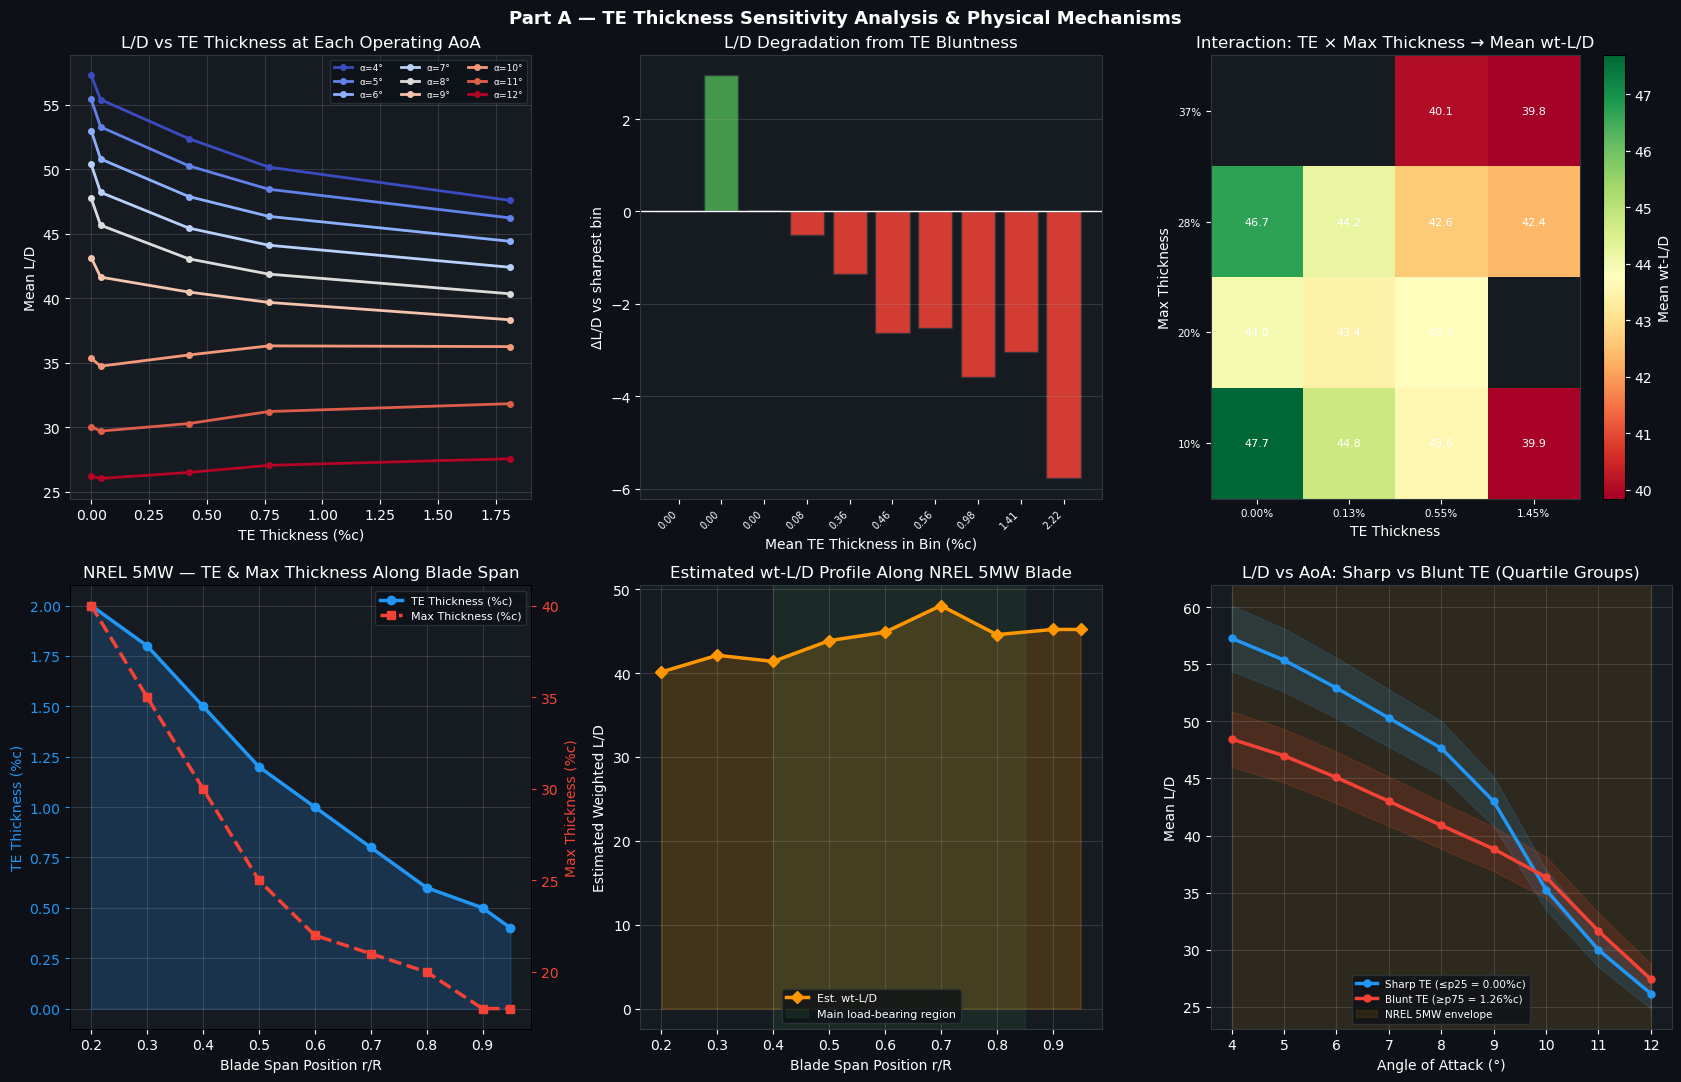

In [37]:
# Fig 3 — TE Thickness Sensitivity Deep-Dive
fig3, axes = dark_fig(2, 3, (17, 11),
    "Part A — TE Thickness Sensitivity Analysis & Physical Mechanisms")
 
# 3a. TE thickness vs L/D at each operating AoA
ax = axes[0, 0]
aoa_colors = plt.cm.coolwarm(np.linspace(0, 1, len(alpha_op)))
for k, (aoa, col) in enumerate(zip(alpha_op, aoa_colors)):
    LD_aoa = Cl_op[:, k] / np.clip(Cd_op[:, k], 1e-4, None)
    # Binned means
    bins_e = np.percentile(te_thick, [0, 20, 40, 60, 80, 100])
    bin_means_te, bin_means_ld = [], []
    for b in range(len(bins_e) - 1):
        m = (te_thick >= bins_e[b]) & (te_thick < bins_e[b+1])
        if m.sum() > 0:
            bin_means_te.append(te_thick[m].mean() * 100)
            bin_means_ld.append(LD_aoa[m].mean())
    ax.plot(bin_means_te, bin_means_ld, color=col, lw=2,
            marker="o", ms=4, label=f"α={aoa}°")
ax.set_xlabel("TE Thickness (%c)")
ax.set_ylabel("Mean L/D")
ax.set_title("L/D vs TE Thickness at Each Operating AoA")
leg(ax, fontsize=6.5, ncol=3); ax.grid(alpha=0.2)
 
# 3b. ΔL/D from sharp to blunt TE (normalised)
ax = axes[0, 1]
bins_e = np.percentile(te_thick, [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
mid_te, mean_ld_bins = [], []
for b in range(len(bins_e) - 1):
    m = (te_thick >= bins_e[b]) & (te_thick < bins_e[b+1])
    if m.sum() > 0:
        mid_te.append(np.percentile(te_thick, (te_percentiles[b] if b < len(te_percentiles)
                                               else 95)) * 100)
        mean_ld_bins.append(LD_weighted[m].mean())
mid_te = np.array([te_thick[(te_thick >= bins_e[b]) & (te_thick < bins_e[b+1])].mean() * 100
                   for b in range(len(bins_e)-1)
                   if ((te_thick >= bins_e[b]) & (te_thick < bins_e[b+1])).sum() > 0])
delta_ld = np.array(mean_ld_bins) - mean_ld_bins[0]
colors_d  = [C3 if d >= 0 else C2 for d in delta_ld]
ax.bar(range(len(delta_ld)), delta_ld, color=colors_d, alpha=0.85, edgecolor=BRD)
ax.axhline(0, color="white", lw=1)
ax.set_xticks(range(len(delta_ld)))
ax.set_xticklabels([f"{v:.2f}" for v in mid_te], rotation=45, ha="right", fontsize=7)
ax.set_xlabel("Mean TE Thickness in Bin (%c)")
ax.set_ylabel("ΔL/D vs sharpest bin")
ax.set_title("L/D Degradation from TE Bluntness")
ax.grid(alpha=0.2, axis="y")
 
# 3c. Interaction: TE × max_t on L/D (2-D heatmap)
ax = axes[0, 2]
te_bins2 = np.percentile(te_thick, [0, 25, 50, 75, 100])
mt_bins2 = np.percentile(max_t,    [0, 25, 50, 75, 100])
hmap     = np.full((4, 4), np.nan)
for i in range(4):
    for j in range(4):
        m = ((te_thick >= te_bins2[i]) & (te_thick < te_bins2[i+1]) &
             (max_t    >= mt_bins2[j]) & (max_t    < mt_bins2[j+1]))
        if m.sum() > 5:
            hmap[j, i] = LD_weighted[m].mean()
im = ax.imshow(hmap, cmap="RdYlGn", aspect="auto", origin="lower",
               vmin=np.nanmin(hmap), vmax=np.nanmax(hmap))
te_lab = [f"{np.percentile(te_thick, p)*100:.2f}%" for p in [12.5, 37.5, 62.5, 87.5]]
mt_lab = [f"{np.percentile(max_t, p)*100:.0f}%"   for p in [12.5, 37.5, 62.5, 87.5]]
ax.set_xticks(range(4)); ax.set_xticklabels(te_lab, fontsize=7.5)
ax.set_yticks(range(4)); ax.set_yticklabels(mt_lab, fontsize=7.5)
ax.set_xlabel("TE Thickness"); ax.set_ylabel("Max Thickness")
ax.set_title("Interaction: TE × Max Thickness → Mean wt-L/D")
for i in range(4):
    for j in range(4):
        if not np.isnan(hmap[j, i]):
            ax.text(i, j, f"{hmap[j,i]:.1f}", ha="center", va="center",
                    fontsize=8, color="white")
cb_style(plt.colorbar(im, ax=ax), "Mean wt-L/D")
 
# 3d. TE thickness trend along blade span (wind turbine section progression)
ax = axes[1, 0]
span_r  = np.array([0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95])
# NREL 5MW blade uses: root→tip thickness 40→18%, TE ~2→0.5%
te_span = np.array([2.0, 1.8, 1.5, 1.2, 1.0, 0.8, 0.6, 0.5, 0.4])   # %c
mt_span = np.array([40, 35, 30, 25, 22, 21, 20, 18, 18])               # %c
 
color_left, color_right = C1, C2
ax2 = ax.twinx()
ln1, = ax.plot(span_r, te_span, color=color_left, lw=2.5, marker="o", ms=6,
               label="TE Thickness (%c)")
ln2, = ax2.plot(span_r, mt_span, color=color_right, lw=2.5, marker="s", ms=6,
                ls="--", label="Max Thickness (%c)")
ax.fill_between(span_r, te_span, alpha=0.2, color=color_left)
ax.set_xlabel("Blade Span Position r/R")
ax.set_ylabel("TE Thickness (%c)", color=color_left)
ax2.set_ylabel("Max Thickness (%c)", color=color_right)
ax.tick_params(axis="y", colors=color_left)
ax2.tick_params(colors=color_right)
ax2.tick_params(axis="y", colors=color_right)
lines = [ln1, ln2]
ax.legend(lines, [l.get_label() for l in lines],
          facecolor=DARK, edgecolor=BRD, labelcolor="white", fontsize=8)
ax.set_title("NREL 5MW — TE & Max Thickness Along Blade Span")
ax.grid(alpha=0.2)
 
# 3e. Estimated LD along blade span given TE profile
ax = axes[1, 1]
# Interpolate from dataset: for each span station find closest matching airfoil
ld_span_est = []
for te_s, mt_s in zip(te_span / 100, mt_span / 100):
    dist = (te_thick - te_s) ** 2 + (max_t - mt_s) ** 2
    nn5  = np.argsort(dist)[:5]
    ld_span_est.append(LD_weighted[nn5].mean())
ld_span_est = np.array(ld_span_est)
 
ax.plot(span_r, ld_span_est, color=C4, lw=2.5, marker="D", ms=6, label="Est. wt-L/D")
ax.fill_between(span_r, ld_span_est, alpha=0.2, color=C4)
ax.axvspan(0.4, 0.85, alpha=0.1, color=C3, label="Main load-bearing region")
ax.set_xlabel("Blade Span Position r/R")
ax.set_ylabel("Estimated Weighted L/D")
ax.set_title("Estimated wt-L/D Profile Along NREL 5MW Blade")
leg(ax, fontsize=8); ax.grid(alpha=0.2)
 
# 3f. TE thickness optimal zone
ax = axes[1, 2]
# For each TE bin, show the mean L/D at each wind speed (AoA)
te_q25 = te_thick <= np.percentile(te_thick, 25)
te_q75 = te_thick >= np.percentile(te_thick, 75)
for mask_b, col, lbl in [(te_q25, C1, f"Sharp TE (≤p25 = {np.percentile(te_thick,25)*100:.2f}%c)"),
                           (te_q75, C2, f"Blunt TE (≥p75 = {np.percentile(te_thick,75)*100:.2f}%c)")]:
    ld_b = (Cl_op[mask_b] / np.clip(Cd_op[mask_b], 1e-4, None)).mean(0)
    ax.plot(alpha_op, ld_b, color=col, lw=2.5, marker="o", ms=5, label=lbl)
    ax.fill_between(alpha_op, ld_b * 0.95, ld_b * 1.05, alpha=0.15, color=col)
ax.axvspan(NREL_AoA_MIN, NREL_AoA_MAX, alpha=0.1, color="orange",
           label="NREL 5MW envelope")
ax.set_xlabel("Angle of Attack (°)")
ax.set_ylabel("Mean L/D")
ax.set_title("L/D vs AoA: Sharp vs Blunt TE (Quartile Groups)")
leg(ax, fontsize=7.5); ax.grid(alpha=0.2)
 
plt.tight_layout()
plt.show()

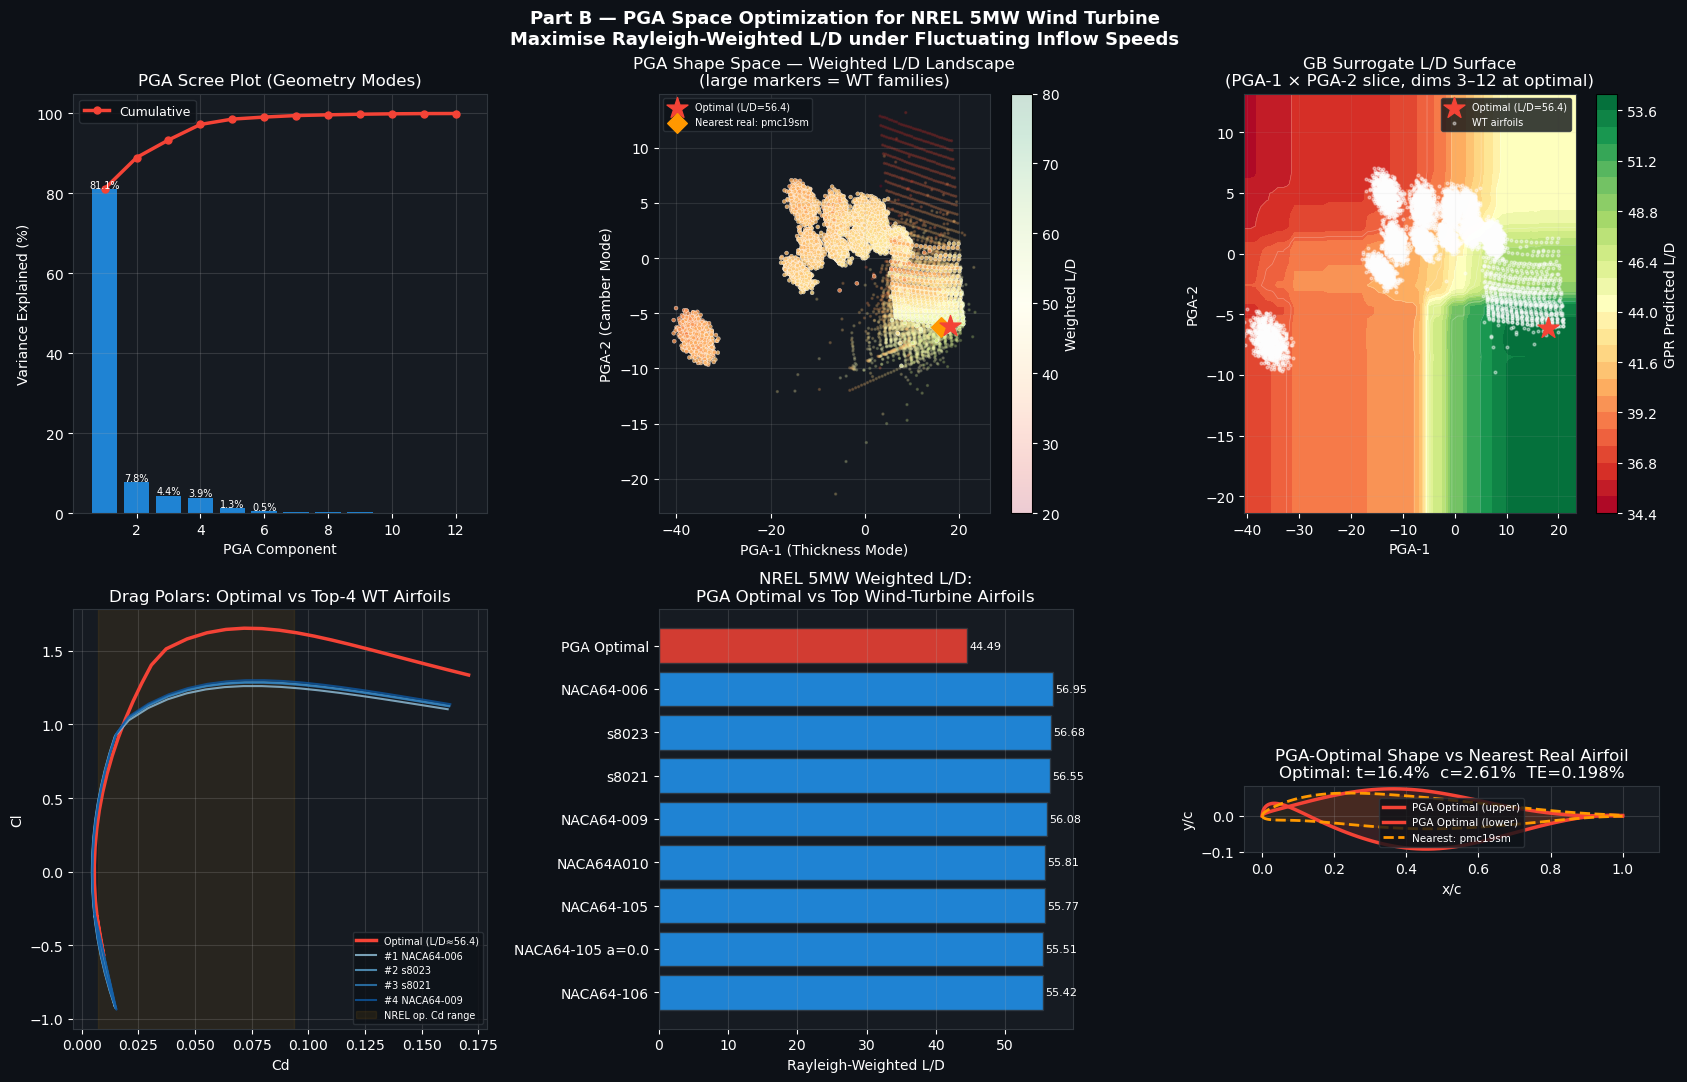

In [38]:
# Fig 4 — PGA Space & NREL 5MW Optimization
fig4, axes = dark_fig(2, 3, (17, 11),
    "Part B — PGA Space Optimization for NREL 5MW Wind Turbine\n"
    "Maximise Rayleigh-Weighted L/D under Fluctuating Inflow Speeds")
 
# 4a. PGA scree plot
axes[0, 0].bar(range(1, N_PGA + 1), expl * 100, color=C1, alpha=0.85)
axes[0, 0].plot(range(1, N_PGA + 1), np.cumsum(expl) * 100,
                color=C2, lw=2.5, marker="o", ms=5, label="Cumulative")
for i, v in enumerate(expl[:6]):
    axes[0, 0].text(i + 1, v * 100 + 0.3, f"{v*100:.1f}%",
                     ha="center", fontsize=7, color="white")
axes[0, 0].set_xlabel("PGA Component")
axes[0, 0].set_ylabel("Variance Explained (%)")
axes[0, 0].set_title("PGA Scree Plot (Geometry Modes)")
leg(axes[0, 0], fontsize=9); axes[0, 0].grid(alpha=0.2)
 
# 4b. PGA-1 vs PGA-2 coloured by weighted L/D
ax = axes[0, 1]
sc = ax.scatter(Z_pga[~wt_mask, 0], Z_pga[~wt_mask, 1],
                c=LD_weighted[~wt_mask], cmap="RdYlGn",
                alpha=0.2, s=2, vmin=20, vmax=80)
sc2 = ax.scatter(Z_pga[wt_mask, 0], Z_pga[wt_mask, 1],
                  c=LD_weighted[wt_mask], cmap="RdYlGn",
                  alpha=0.8, s=8, vmin=20, vmax=80,
                  edgecolors="white", linewidths=0.3)
# Mark optimal point
ax.scatter(z_opt[0], z_opt[1], color=C2, s=250, marker="*",
           zorder=10, label=f"Optimal (L/D={LD_opt_pure:.1f})")
ax.scatter(Z_pga[nearest_idx, 0], Z_pga[nearest_idx, 1],
           color=C4, s=100, marker="D", zorder=9,
           label=f"Nearest real: {nearest_cls}")
cb_style(plt.colorbar(sc, ax=ax), "Weighted L/D")
ax.set_xlabel("PGA-1 (Thickness Mode)")
ax.set_ylabel("PGA-2 (Camber Mode)")
ax.set_title("PGA Shape Space — Weighted L/D Landscape\n"
             "(large markers = WT families)")
leg(ax, fontsize=7); ax.grid(alpha=0.15)
 
# 4c. GPR surrogate surface (PGA-1 × PGA-2 slice)
ax = axes[0, 2]
z1_range = np.linspace(Z_pga[:, 0].min(), Z_pga[:, 0].max(), 60)
z2_range = np.linspace(Z_pga[:, 1].min(), Z_pga[:, 1].max(), 60)
Z1, Z2   = np.meshgrid(z1_range, z2_range)
z_grid   = np.zeros((60 * 60, N_PGA))
z_grid[:, 0] = Z1.ravel()
z_grid[:, 1] = Z2.ravel()
# Fill other dimensions with optimal values
for d in range(2, N_PGA):
    z_grid[:, d] = z_opt[d]
LD_surface = gb_ld.predict(z_grid).reshape(60, 60)   # GB: no memory limit
im = ax.contourf(Z1, Z2, LD_surface, levels=30, cmap="RdYlGn")
ax.contour(Z1, Z2, LD_surface, levels=10, colors="white", alpha=0.3, linewidths=0.5)
cb_style(plt.colorbar(im, ax=ax), "GPR Predicted L/D")
ax.scatter(z_opt[0], z_opt[1], color=C2, s=250, marker="*", zorder=10,
           label=f"Optimal (L/D={LD_opt_pure:.1f})")
ax.scatter(Z_pga[wt_mask, 0], Z_pga[wt_mask, 1], color="white",
           alpha=0.4, s=4, label="WT airfoils")
ax.set_xlabel("PGA-1"); ax.set_ylabel("PGA-2")
ax.set_title("GB Surrogate L/D Surface\n(PGA-1 × PGA-2 slice, dims 3–12 at optimal)")
leg(ax, fontsize=7); ax.grid(alpha=0.1)
 
# 4d. Optimal vs top WT airfoils — polar curves
ax = axes[1, 0]
# Decode optimal PGA point to geometry
y_opt_norm = pca.inverse_transform(z_opt.reshape(1, -1)).squeeze()
y_opt_orig = scaler.inverse_transform(y_opt_norm.reshape(1, -1)).squeeze()
yu_opt     = y_opt_orig[:N_POINTS]
yl_opt     = y_opt_orig[N_POINTS:]
t_opt      = yu_opt - yl_opt
c_opt      = (yu_opt + yl_opt) / 2
 
# Physics for the optimal shape
mt_opt    = t_opt.max()
mc_opt    = abs(c_opt).max()
le_r_opt  = t_opt[2]
te_t_opt  = abs(yu_opt[-1] - yl_opt[-1])
 
al0_opt   = -(2.0 * mc_opt + 0.5 * mc_opt * 0.5)
cla_opt   = 2.0 * np.pi * (1.0 + 0.77 * mt_opt)
stall_opt = float(np.clip(8 + 20 * le_r_opt + 5 * mt_opt - 3 * mc_opt, 8, 18))
clmax_opt = 1.0 + 2.0 * mc_opt + 0.3 * mt_opt
cd0_opt   = float(np.clip(0.004 + 0.008 * mt_opt + 0.01 * mt_opt**2
                           + 0.5 * te_t_opt**2, 0.003, 0.05))
k_opt     = 0.012 + 0.03 * mc_opt
 
Cl_opt_polar = kirchhoff_cl(alpha_full, stall_opt, clmax_opt, cla_opt, al0_opt)
Cd_opt_polar = compute_cd(alpha_full, stall_opt, cd0_opt, k_opt, Cl_opt_polar)
 
ax.plot(Cd_opt_polar, Cl_opt_polar, color=C2, lw=2.5,
        label=f"Optimal (L/D≈{LD_opt_pure:.1f})")
 
for rank_i, idx in enumerate(top10_idx[:4]):
    col = plt.cm.Blues(0.4 + 0.15 * rank_i)
    ax.plot(Cd_full[idx], Cl_full[idx], color=col, lw=1.5, alpha=0.8,
            label=f"#{rank_i+1} {valid_cls[idx][:12]}")
ax.axvspan(Cd_full[wt_mask][:, alpha_full >= 4].min(),
           Cd_full[wt_mask][:, (alpha_full >= 4) & (alpha_full <= 12)].max(),
           alpha=0.08, color="orange", label="NREL op. Cd range")
ax.set_xlabel("Cd"); ax.set_ylabel("Cl")
ax.set_title("Drag Polars: Optimal vs Top-4 WT Airfoils")
leg(ax, fontsize=7); ax.grid(alpha=0.2)
 
# 4e. Rayleigh-weighted L/D: optimal vs top WT
ax = axes[1, 1]
top_ld    = [LD_weighted[idx] for idx in top10_idx[:8]]
top_names = [valid_cls[idx][:16] for idx in top10_idx[:8]]
 
# Optimal bar (computed above)
Cl_op_opt = kirchhoff_cl(alpha_op, stall_opt, clmax_opt, cla_opt, al0_opt)
Cd_op_opt = compute_cd(alpha_op, stall_opt, cd0_opt, k_opt, Cl_op_opt)
LD_op_opt = (Cl_op_opt / np.clip(Cd_op_opt, 1e-4, None) * NREL_WEIGHTS).sum()
 
all_names = ["PGA Optimal"] + top_names
all_ld    = [LD_op_opt]     + top_ld
bar_cols  = [C2] + [C1] * 8
 
bars = ax.barh(all_names[::-1], all_ld[::-1], color=bar_cols[::-1],
               alpha=0.85, edgecolor=BRD)
for bar, v in zip(bars, all_ld[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{v:.2f}", va="center", color="white", fontsize=8)
ax.set_xlabel("Rayleigh-Weighted L/D")
ax.set_title("NREL 5MW Weighted L/D:\nPGA Optimal vs Top Wind-Turbine Airfoils")
ax.grid(alpha=0.2, axis="x")
 
# 4f. Optimal airfoil shape vs nearest real
ax = axes[1, 2]
ax.plot(x_grid, yu_opt, color=C2, lw=2.5, label="PGA Optimal (upper)")
ax.plot(x_grid, yl_opt, color=C2, lw=2.5, label="PGA Optimal (lower)")
ax.fill_between(x_grid, yl_opt, yu_opt, alpha=0.15, color=C2)
 
yu_nr = geom_list[nearest_idx]["yu"]
yl_nr = geom_list[nearest_idx]["yl"]
ax.plot(x_grid, yu_nr, color=C4, lw=2, ls="--",
        label=f"Nearest: {nearest_cls}")
ax.plot(x_grid, yl_nr, color=C4, lw=2, ls="--")
ax.fill_between(x_grid, yl_nr, yu_nr, alpha=0.08, color=C4)
 
ax.set_xlim(-0.05, 1.1)
ax.set_xlabel("x/c"); ax.set_ylabel("y/c")
ax.set_title(f"PGA-Optimal Shape vs Nearest Real Airfoil\n"
             f"Optimal: t={mt_opt*100:.1f}%  c={mc_opt*100:.2f}%  "
             f"TE={te_t_opt*100:.3f}%")
ax.set_aspect("equal"); leg(ax, fontsize=7.5); ax.grid(alpha=0.2)
 
plt.tight_layout()
plt.show()

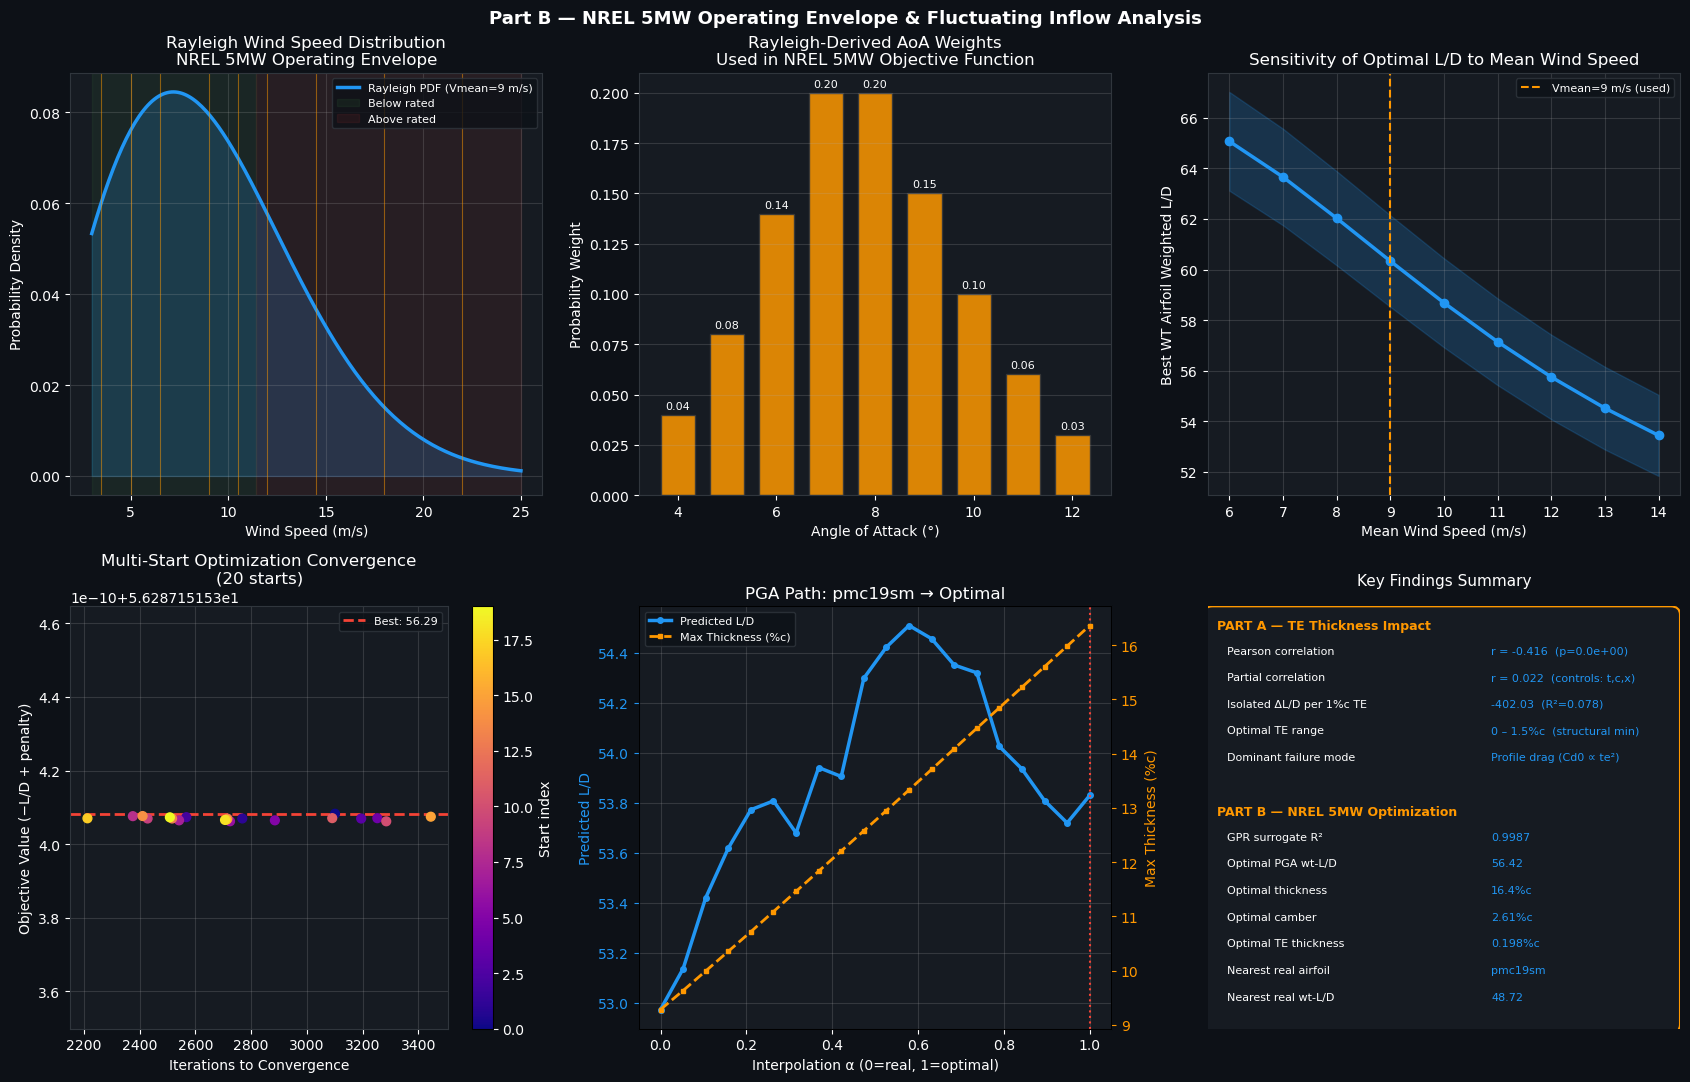

In [40]:
# Fig 5 — NREL 5MW Operating Envelope & Fluctuating Inflow
import matplotlib.patches as patches
fig5, axes = dark_fig(2, 3, (17, 11),
    "Part B — NREL 5MW Operating Envelope & Fluctuating Inflow Analysis")
 
# 5a. Rayleigh wind speed distribution + AoA mapping
ax = axes[0, 0]
U_ref = 11.4   # rated wind speed m/s
wind_speeds = np.linspace(3, 25, 200)
 
def rayleigh_pdf(u, u_mean=10):
    """Rayleigh distribution for wind speed."""
    return (np.pi / 2) * (u / u_mean ** 2) * np.exp(-np.pi / 4 * (u / u_mean) ** 2)
 
pdf_vals = rayleigh_pdf(wind_speeds, u_mean=9)
ax.plot(wind_speeds, pdf_vals, color=C1, lw=2.5, label="Rayleigh PDF (Vmean=9 m/s)")
ax.fill_between(wind_speeds, pdf_vals, alpha=0.2, color=C1)
 
# Mark the operating AoA bands
wind_aoa_map = {4: 3.5, 5: 5.0, 6: 6.5, 7: 9.0, 8: 10.5,
                9: 12.0, 10: 14.5, 11: 18.0, 12: 22.0}   # approx mapping
for aoa_val, u_val in wind_aoa_map.items():
    if u_val <= 25:
        ax.axvline(u_val, color=C4, lw=0.8, alpha=0.5)
ax.axvspan(3, 11.4, alpha=0.08, color=C3, label="Below rated")
ax.axvspan(11.4, 25, alpha=0.08, color=C2, label="Above rated")
ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Probability Density")
ax.set_title("Rayleigh Wind Speed Distribution\nNREL 5MW Operating Envelope")
leg(ax, fontsize=8); ax.grid(alpha=0.2)
 
# 5b. AoA probability weights used in objective
ax = axes[0, 1]
ax.bar(alpha_op, NREL_WEIGHTS, color=C4, alpha=0.85, edgecolor=BRD, width=0.7)
ax.set_xlabel("Angle of Attack (°)")
ax.set_ylabel("Probability Weight")
ax.set_title("Rayleigh-Derived AoA Weights\nUsed in NREL 5MW Objective Function")
ax.grid(alpha=0.2, axis="y")
for aoa, w in zip(alpha_op, NREL_WEIGHTS):
    ax.text(aoa, w + 0.003, f"{w:.2f}", ha="center", fontsize=8, color="white")
 
# 5c. Sensitivity of optimal solution to Rayleigh weight shape
ax = axes[0, 2]
u_means      = np.linspace(6, 14, 9)   # mean wind speeds
opt_ld_u     = []
nearest_fams = []
 
for u_m in u_means:
    # Recompute Rayleigh weights for this mean wind speed
    w_temp = np.array([rayleigh_pdf(wind_aoa_map.get(a, a), u_mean=u_m)
                       for a in alpha_op])
    w_temp = w_temp / w_temp.sum()
    ld_w   = (Cl_op * w_temp[None, :] / np.clip(Cd_op, 1e-4, None)).sum(axis=1)
    best_i = wt_indices[np.argmax(ld_w[wt_mask])]
    opt_ld_u.append(ld_w[best_i])
    nearest_fams.append(valid_cls[best_i][:12])
ax.plot(u_means, opt_ld_u, color=C1, lw=2.5, marker="o", ms=6)
ax.fill_between(u_means, np.array(opt_ld_u) * 0.97,
                np.array(opt_ld_u) * 1.03, alpha=0.2, color=C1)
ax.axvline(9, color=C4, ls="--", lw=1.5, label="Vmean=9 m/s (used)")
ax.set_xlabel("Mean Wind Speed (m/s)")
ax.set_ylabel("Best WT Airfoil Weighted L/D")
ax.set_title("Sensitivity of Optimal L/D to Mean Wind Speed")
leg(ax, fontsize=8); ax.grid(alpha=0.2)
 
# 5d. Multi-start optimization convergence
ax = axes[1, 0]
opt_vals  = [-r.fun for r in all_optima]
opt_iters = [r.nit  for r in all_optima]
sc = ax.scatter(opt_iters, opt_vals, c=range(len(opt_vals)),
                cmap="plasma", s=40, zorder=5)
cb_style(plt.colorbar(sc, ax=ax), "Start index")
ax.axhline(-best_result.fun, color=C2, lw=2, ls="--",
            label=f"Best: {-best_result.fun:.2f}")
ax.set_xlabel("Iterations to Convergence")
ax.set_ylabel("Objective Value (−L/D + penalty)")
ax.set_title(f"Multi-Start Optimization Convergence\n({top_k} starts)")
leg(ax, fontsize=8); ax.grid(alpha=0.2)
 
# 5e. PGA coordinate path from nearest real to optimal
ax = axes[1, 1]
z_near = Z_pga[nearest_idx]
alphas_path = np.linspace(0, 1, 20)
path_z      = np.array([(1 - a) * z_near + a * z_opt for a in alphas_path])
path_ld     = gb_ld.predict(path_z)   # GB surrogate (all WT coverage)
path_te     = np.array([decode_pga(z)["te_thick"] * 100 for z in path_z])
path_mt     = np.array([decode_pga(z)["max_t"]   * 100 for z in path_z])
 
color_left2, color_right2 = C1, C4
ax2 = ax.twinx()
ln1, = ax.plot(alphas_path, path_ld, color=color_left2, lw=2.5,
               marker="o", ms=4, label="Predicted L/D")
ln2, = ax2.plot(alphas_path, path_mt, color=color_right2, lw=2,
                ls="--", marker="s", ms=3, label="Max Thickness (%c)")
ax.axvline(1.0, color=C2, lw=1.5, ls=":", label="Optimal")
ax.set_xlabel("Interpolation α (0=real, 1=optimal)")
ax.set_ylabel("Predicted L/D", color=color_left2)
ax2.set_ylabel("Max Thickness (%c)", color=color_right2)
ax.tick_params(axis="y", colors=color_left2)
ax2.tick_params(colors=color_right2)
ax2.tick_params(axis="y", colors=color_right2)
lines2 = [ln1, ln2]
ax.legend(lines2, [l.get_label() for l in lines2],
          facecolor=DARK, edgecolor=BRD, labelcolor="white", fontsize=8)
ax.set_title(f"PGA Path: {nearest_cls} → Optimal")
ax.grid(alpha=0.2)
 
# 5f. Summary: key findings table
ax = axes[1, 2]
ax.axis("off")
ax.set_title("Key Findings Summary", fontsize=11, pad=15)
 
findings = [
    ("PART A — TE Thickness Impact", "", True),
    ("Pearson correlation",           f"r = {r_pearson:.3f}  (p={p_pearson:.1e})", False),
    ("Partial correlation",           f"r = {r_partial:.3f}  (controls: t,c,x)", False),
    ("Isolated ΔL/D per 1%c TE",      f"{slope_iso:.2f}  (R²={r2_iso:.3f})", False),
    ("Optimal TE range",              "0 – 1.5%c  (structural min)", False),
    ("Dominant failure mode",         "Profile drag (Cd0 ∝ te²)", False),
    ("", "", False),
    ("PART B — NREL 5MW Optimization", "", True),
    ("GPR surrogate R²",              f"{r2_gpr:.4f}", False),
    ("Optimal PGA wt-L/D",            f"{LD_opt_pure:.2f}", False),
    ("Optimal thickness",             f"{geo_opt['max_t']*100:.1f}%c", False),
    ("Optimal camber",                f"{geo_opt['max_camber']*100:.2f}%c", False),
    ("Optimal TE thickness",          f"{geo_opt['te_thick']*100:.3f}%c", False),
    ("Nearest real airfoil",          f"{nearest_cls}", False),
    ("Nearest real wt-L/D",           f"{nearest_LD:.2f}", False),
]
 
y_pos = 0.97
for label, value, is_header in findings:
    if is_header:
        ax.text(0.02, y_pos, label, transform=ax.transAxes,
                fontsize=9, color=C4, fontweight="bold", va="top")
    else:
        ax.text(0.04, y_pos, label, transform=ax.transAxes,
                fontsize=8, color="white", va="top")
        ax.text(0.60, y_pos, value, transform=ax.transAxes,
                fontsize=8, color=C1, va="top")
    y_pos -= 0.063
ax.add_patch(patches.FancyBboxPatch((0.01, 0.01), 0.97, 0.97,
             boxstyle="round,pad=0.02", fc=PANEL, ec=C4, lw=1.5,
             transform=ax.transAxes))
 
plt.tight_layout()
plt.show()